## About the dataset
This dataset can be used to classify the type of mole into cancerous or non cancerous. It contains a balanced dataset of images of benign skin moles and malignant skin moles. The data consists of 1800 images with size 224 x 224.

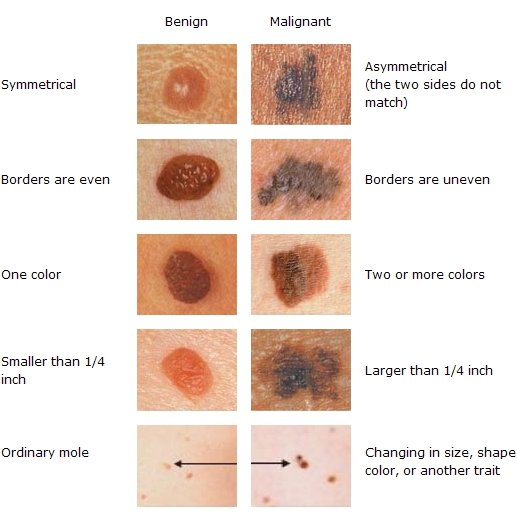

In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [ ]:
# Skin Cancer detection using a pre trained model VGG19.

# Dataset can be downloaded from
# https://www.kaggle.com/fanconic/skin-cancer-malignant-vs-benign

from keras.layers import Input, Lambda, Dense, Flatten
from keras.models import Model
#from keras.applications.vgg16 import VGG16
from keras.applications.vgg19 import VGG19
from keras.applications.vgg19 import preprocess_input
from keras.preprocessing import image
from keras.preprocessing.image import ImageDataGenerator
from keras.models import Sequential
import numpy as np
from glob import glob
import matplotlib.pyplot as plt
import random 
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import Dropout


In [ ]:
# re-size all the images to standard size 224 x 224
IMAGE_SIZE = [224, 224]

# specifying path for train and test data folders
train_path = '../input/skin-cancer-malignant-vs-benign/train'
valid_path = '../input/skin-cancer-malignant-vs-benign/test'

## Dataset image Visualization

In [ ]:
#function to visualize image
def plot_image(file, directory=None, sub=False, aspect=None):
    path = directory + file
    
    img = plt.imread(path)
    
    plt.imshow(img, aspect=aspect)
#     plt.title(file)
    plt.xticks([])
    plt.yticks([])
    
    if sub:
        plt.show()

In [ ]:
def plot_img_dir(directory=train_path, count=5):
    selected_files = random.sample(os.listdir(directory), count)
    
    ncols = 5
    nrows = count//ncols if count%ncols==0 else count//ncols+1
    
    figsize=(20, ncols*nrows)

    ticksize = 14
    titlesize = ticksize + 8
    labelsize = ticksize + 5


    params = {'figure.figsize' : figsize,
              'axes.labelsize' : labelsize,
              'axes.titlesize' : titlesize,
              'xtick.labelsize': ticksize,
              'ytick.labelsize': ticksize}

    plt.rcParams.update(params)
    
    i=0
    
    for file in selected_files:        
        plt.subplot(nrows, ncols, i+1)
        path = directory + file
        plot_image(file, directory, aspect=None)

        i=i+1
    
    plt.tight_layout()
    plt.show()
    
def plot_img_dir_main(directory=train_path, count=5):
    labels = os.listdir(directory)
    for label in labels:
        print(label)
        plot_img_dir(directory=directory+"/"+label+"/", count=count)
        

benign


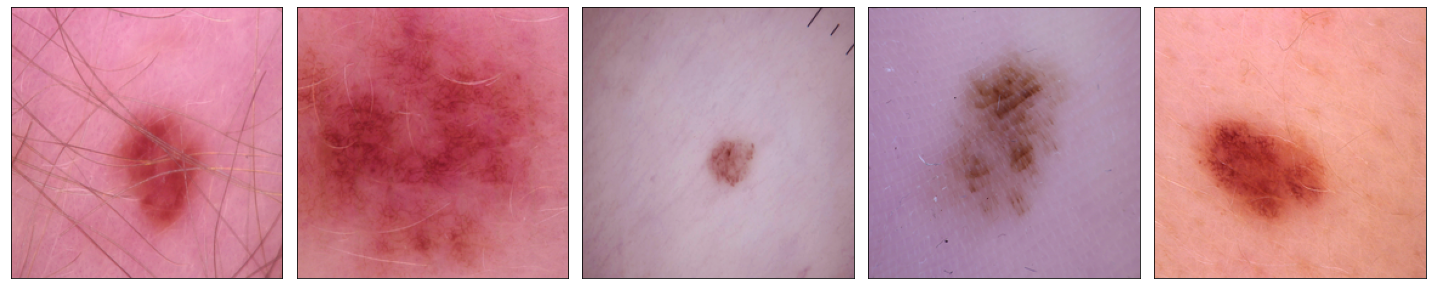

malignant


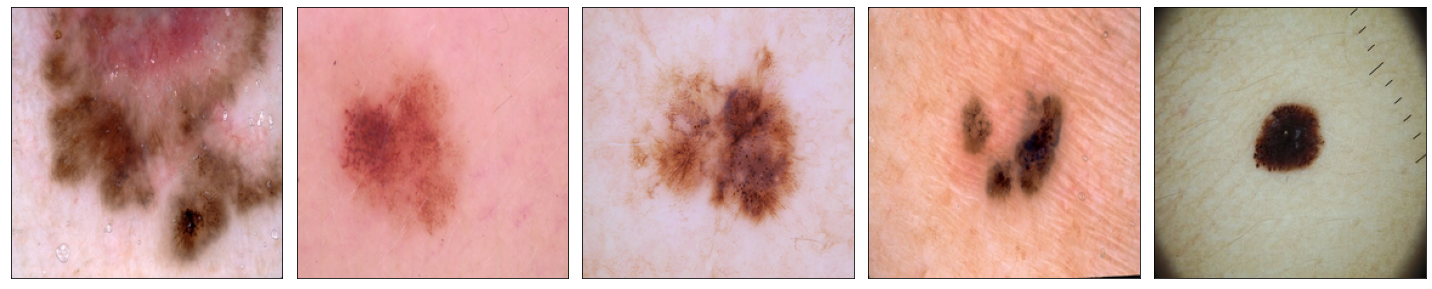

In [ ]:
plot_img_dir_main(directory=train_path, count=5)

## Model Implementation (VGG 19) using Transfer Learning

In [ ]:
# added preprocessing layer to the front of VGG
vgg = VGG19(input_shape=IMAGE_SIZE + [3], weights='imagenet', include_top=False)



80142336/80134624 [==============================] - 2s 0us/step


In [ ]:
# Freezing the existing layers 
for layer in vgg.layers:
  layer.trainable = False
  

In [ ]:

# fetching number of classes
folders = glob('../input/skin-cancer-malignant-vs-benign/train/*')

In [ ]:
folders


['../input/skin-cancer-malignant-vs-benign/train/benign',
 '../input/skin-cancer-malignant-vs-benign/train/malignant']

In [ ]:
len(folders)

2

We will then build the last fully-connected layer. I have just used the basic settings, but feel free to experiment with different values of dropout, and different Optimisers and activation functions.

## Addition of fully connected layer in the last layers

In [ ]:
# Flatten the output layer to 1 dimension
#x = layers.Flatten()(base_model.output)
x = Flatten()(vgg.output)

# Add a fully connected layer with 512 hidden units and ReLU activation
x = Dense(512, activation='relu')(x)

# Add a dropout rate of 0.5
x = Dropout(0.5)(x)

# Add a fully connected layer with 256 hidden units and ReLU activation
x = Dense(256, activation='relu')(x)

# Add a dropout rate of 0.5
x = Dropout(0.5)(x)

# Add a final sigmoid layer for classification
prediction = Dense(len(folders), activation='softmax')(x)

#model = tf.keras.models.Model(base_model.input, x)

#model.compile(optimizer = tf.keras.optimizers.RMSprop(lr=0.0001), loss = 'binary_crossentropy',metrics = ['acc'])

In [ ]:
# model object creation
model = Model(inputs=vgg.input, outputs=prediction)

## Model Summary

In [ ]:
# view model structure
model.summary()


Model: "model_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_1 (InputLayer)         [(None, 224, 224, 3)]     0         
_________________________________________________________________
block1_conv1 (Conv2D)        (None, 224, 224, 64)      1792      
_________________________________________________________________
block1_conv2 (Conv2D)        (None, 224, 224, 64)      36928     
_________________________________________________________________
block1_pool (MaxPooling2D)   (None, 112, 112, 64)      0         
_________________________________________________________________
block2_conv1 (Conv2D)        (None, 112, 112, 128)     73856     
_________________________________________________________________
block2_conv2 (Conv2D)        (None, 112, 112, 128)     147584    
_________________________________________________________________
block2_pool (MaxPooling2D)   (None, 56, 56, 128)       0   

In [ ]:
# setting model cost and optimization method to use
model.compile(
  loss='categorical_crossentropy',
  optimizer='adam',
  metrics=['accuracy']
)


## Implementing Data Augmentation

In [ ]:
# Image Data Generator to import the images from the dataset
from keras.preprocessing.image import ImageDataGenerator

Image Augmentation
Since we took up a much smaller dataset of images earlier, we can make up for it by augmenting this data and increasing our dataset size. If you are working with the original larger dataset, you can skip this step and move straight on to building the model.

In [ ]:
# Addition of data-augmentation parameters to ImageDataGenerator
train_datagen = ImageDataGenerator(rescale = 1./255,
                                   shear_range = 0.2,
                                   zoom_range = 0.2,
                                   width_shift_range = 0.2,
                                   height_shift_range = 0.2,
                                   rotation_range = 40,
                                   horizontal_flip = True)
 

In [ ]:
# validation data should not be augmented
test_datagen = ImageDataGenerator(rescale = 1./255)

training_set = train_datagen.flow_from_directory('../input/skin-cancer-malignant-vs-benign/train',
                                                 target_size = (224, 224),
                                                 batch_size = 64,
                                                 class_mode = 'categorical')

test_set = test_datagen.flow_from_directory('../input/skin-cancer-malignant-vs-benign/test',
                                            target_size = (224, 224),
                                            batch_size = 64,
                                            class_mode = 'categorical')

Found 2637 images belonging to 2 classes.
Found 660 images belonging to 2 classes.


In [ ]:
# number of  benign test data
DIR = '../input/skin-cancer-malignant-vs-benign/test/benign'
benign_test = ([name for name in os.listdir(DIR) if os.path.isfile(os.path.join(DIR, name))])
print("number of benign test data:" + str(len(benign_test)))

number of benign test data:360


In [ ]:
# number of malignant test data
DIR = '../input/skin-cancer-malignant-vs-benign/test/malignant'
malignant_test = ([name for name in os.listdir(DIR) if os.path.isfile(os.path.join(DIR, name))])
print("number of malignant test data:" + str(len(malignant_test)))

number of malignant test data:300


In [ ]:
# number of malignant train data
DIR = '../input/skin-cancer-malignant-vs-benign/train/malignant'
malignant_train = ([name for name in os.listdir(DIR) if os.path.isfile(os.path.join(DIR, name))])
print("number of malignant train data:" + str(len(malignant_train)))

number of malignant train data:1197


In [ ]:
# number of malignant train data 
DIR = '../input/skin-cancer-malignant-vs-benign/train/benign'
benign_train = ([name for name in os.listdir(DIR) if os.path.isfile(os.path.join(DIR, name))])
print("number of benign train data:" + str(len(benign_train)))

number of benign train data:1440


In [ ]:
from keras.callbacks import ReduceLROnPlateau
learning_rate_reduction = ReduceLROnPlateau(monitor='val_accuracy', patience = 2, verbose=1,factor=0.3, min_lr=0.000001)

## Model Fitting


In [ ]:
# fit the model
r = model.fit_generator(
  training_set,
  validation_data=test_set,
  epochs=12,
  steps_per_epoch=len(training_set),
  validation_steps=len(test_set),
  callbacks = [learning_rate_reduction]
)

/opt/conda/lib/python3.7/site-packages/tensorflow/python/keras/engine/training.py:1844: UserWarning: `Model.fit_generator` is deprecated and will be removed in a future version. Please use `Model.fit`, which supports generators.
  warnings.warn('`Model.fit_generator` is deprecated and '


Epoch 1/12
42/42 [==============================] - 74s 1s/step - loss: 2.7160 - accuracy: 0.5331 - val_loss: 0.4712 - val_accuracy: 0.7848
Epoch 2/12
42/42 [==============================] - 42s 999ms/step - loss: 0.6139 - accuracy: 0.6766 - val_loss: 0.4146 - val_accuracy: 0.8045
Epoch 3/12
42/42 [==============================] - 42s 1s/step - loss: 0.4989 - accuracy: 0.7639 - val_loss: 0.4049 - val_accuracy: 0.8152
Epoch 4/12
42/42 [==============================] - 42s 991ms/step - loss: 0.4673 - accuracy: 0.7702 - val_loss: 0.3877 - val_accuracy: 0.8091
Epoch 5/12
42/42 [==============================] - 41s 987ms/step - loss: 0.5038 - accuracy: 0.7426 - val_loss: 0.4532 - val_accuracy: 0.7970

Epoch 00005: ReduceLROnPlateau reducing learning rate to 0.0003000000142492354.
Epoch 6/12
42/42 [==============================] - 42s 991ms/step - loss: 0.4706 - accuracy: 0.7873 - val_loss: 0.3932 - val_accuracy: 0.8212
Epoch 7/12
42/42 [==============================] - 42s 1s/step - l

In [ ]:

X_test, y_test = next(test_set)

In [ ]:
print("Loss of the model is - " , model.evaluate(X_test,y_test)[0])
print("Accuracy of the model is - " , model.evaluate(X_test,y_test)[1]*100 , "%")

2/2 [==============================] - 3s 76ms/step - loss: 0.4345 - accuracy: 0.7969
Loss of the model is -  0.43450477719306946
2/2 [==============================] - 0s 77ms/step - loss: 0.4345 - accuracy: 0.7969
Accuracy of the model is -  79.6875 %


## Loss and Accuracy Visualization

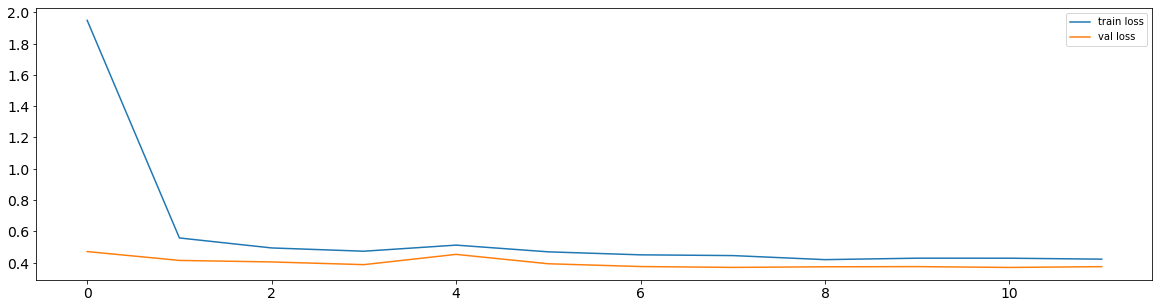

<Figure size 1440x360 with 0 Axes>

In [ ]:
# loss visualization
plt.plot(r.history['loss'], label='train loss')
plt.plot(r.history['val_loss'], label='val loss')
plt.legend()
plt.show()
plt.savefig('LossVal_loss')



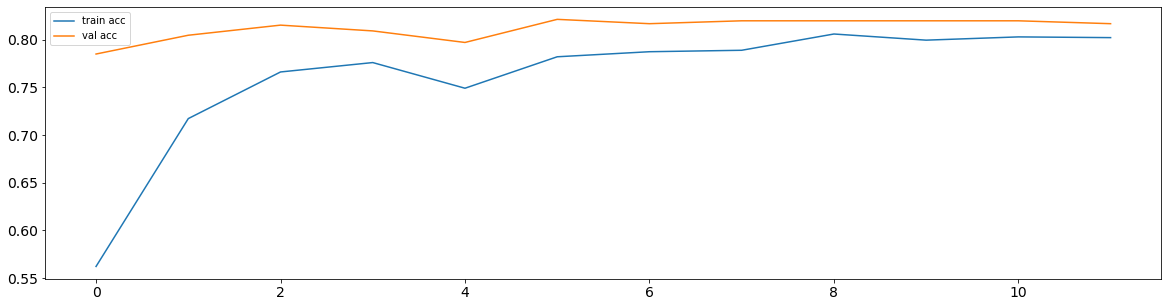

<Figure size 1440x360 with 0 Axes>

In [ ]:
# accuracies visualization
plt.plot(r.history['accuracy'], label='train acc')
plt.plot(r.history['val_accuracy'], label='val acc')
plt.legend()
plt.show()
plt.savefig('AccVal_acc')



## Saving the fine-tuned model

In [ ]:
import tensorflow as tf

from keras.models import load_model

# save the fine tuned model
model.save('model_vgg19.h5')

In [ ]:
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image

## Model Prediction

In [ ]:
# loading back the saved model
model=load_model('model_vgg19.h5')

In [ ]:
img=image.load_img('../input/skin-cancer-malignant-vs-benign/test/benign/1006.jpg',target_size=(224,224))



In [ ]:
x=image.img_to_array(img)
x

array([[[234., 141., 160.],
        [233., 138., 158.],
        [235., 142., 161.],
        ...,
        [240., 165., 185.],
        [240., 165., 185.],
        [239., 166., 183.]],

       [[234., 137., 157.],
        [234., 135., 156.],
        [235., 137., 162.],
        ...,
        [239., 166., 183.],
        [242., 168., 185.],
        [240., 166., 181.]],

       [[232., 138., 154.],
        [232., 138., 156.],
        [232., 139., 158.],
        ...,
        [244., 170., 193.],
        [242., 169., 188.],
        [240., 169., 183.]],

       ...,

       [[221., 144., 162.],
        [221., 153., 168.],
        [221., 150., 164.],
        ...,
        [223., 162., 170.],
        [220., 160., 168.],
        [220., 161., 167.]],

       [[213., 133., 144.],
        [218., 144., 157.],
        [225., 145., 158.],
        ...,
        [222., 162., 170.],
        [217., 158., 164.],
        [222., 161., 168.]],

       [[212., 135., 143.],
        [214., 131., 139.],
        [218., 1

In [ ]:
x.shape

(224, 224, 3)

In [ ]:
x=x/255

In [ ]:
x=np.expand_dims(x,axis=0)
img_data=preprocess_input(x)
img_data.shape

(1, 224, 224, 3)

In [ ]:
# model prediction on an image
model.predict(img_data)

array([[0.773562  , 0.22643797]], dtype=float32)

In [ ]:
a=np.argmax(model.predict(img_data), axis=1)

In [ ]:
if(a==1):
    print("Uninfected")
else:
    print("Infected")

Infected
